In [3]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading and Inspecting Data
file_path = (r"C:\Users\moses_y\OneDrive\Desktop\Solar Electricity\Junior Data Analyst _ Data.xlsx") # Path to the Excel file
raw_data = pd.read_excel(file_path, sheet_name='Raw Data')

raw_data.head()

,Hour 0 represents the hour from midnight to 01:00 and hour 23 represents the hour from 23:00 to midnight.,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,DATA,DATA
1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
2,0,2020-01-01 00:00:00,0,1.509849
3,1,2020-01-01 01:00:00,0,1.411859
4,2,2020-01-01 02:00:00,0,1.023898


In [4]:
# Setting the correct header and removing unnecessary rows
raw_data.columns = raw_data.iloc[1]
raw_data = raw_data[2:].reset_index(drop=True)

# Converting the "Date/hour start" column to a datetime object
raw_data['Date/hour start'] = pd.to_datetime(raw_data['Date/hour start'])

# Converting the other columns to numeric
raw_data['Solar electricity generation (kWh)'] = pd.to_numeric(raw_data['Solar electricity generation (kWh)'])
raw_data['Electricity usage (kWh)'] = pd.to_numeric(raw_data['Electricity usage (kWh)'])

# Displaying the cleaned data
raw_data.head()


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
0,0,2020-01-01 00:00:00,0.0,1.509849
1,1,2020-01-01 01:00:00,0.0,1.411859
2,2,2020-01-01 02:00:00,0.0,1.023898
3,3,2020-01-01 03:00:00,0.0,0.642000
4,4,2020-01-01 04:00:00,0.0,0.960000


The data is now properly structured, with the following columns:

**Hour**: Represents the hour of the day.
**Date/hour start**: The timestamp for the start of the hour.

**Solar electricity generation (kWh)**: The amount of solar electricity generated during that hour.

**Electricity usage (kWh)**: The amount of electricity used during that hour.

Next, let's perform some basic checks to confirm that the data is complete and fit for use. We'll check for any missing values and summarize the basic statistics for each column.

In [5]:
# Checking for missing values
missing_values = raw_data.isnull().sum()

# Summarizing basic statistics for each column
basic_statistics = raw_data.describe()

missing_values, basic_statistics


(1
 Hour                                  0
 Date/hour start                       0
 Solar electricity generation (kWh)    0
 Electricity usage (kWh)               0
 dtype: int64,
 1                    Date/hour start  Solar electricity generation (kWh)  \
 count                           8760                         8760.000000   
 mean   2020-07-02 07:37:13.972602624                            1.116750   
 min              2020-01-01 00:00:00                            0.000000   
 25%              2020-04-02 05:45:00                            0.000000   
 50%              2020-07-02 11:30:00                            0.024000   
 75%              2020-10-01 17:15:00                            1.272750   
 max              2020-12-31 23:00:00                           13.050000   
 std                              NaN                            2.026098   
 
 1      Electricity usage (kWh)  
 count              8760.000000  
 mean                  7.312704  
 min                 

The basic checks reveal the following information:

**Missing Values:** There are no missing values in any of the columns.

### Statistics:
The "Hour" column ranges from 0 to 23, representing the 24 hours of the day.

The "Solar electricity generation (kWh)" column has a minimum value of 0 and a maximum value of 13.05.

The "Electricity usage (kWh)" column shows some interesting statistics, with a minimum value of -12.624 and a maximum value of 46000, indicating potential outliers.

We have successfully loaded and understood the basic structure of the data. 

## Part (i): Graphs, Outliers, and Corrections

### (i.a) Graph Showing the Average Solar Electricity Generation and Average Electricity Usage for Each Hour

We'll create a graph that displays the average solar electricity generation and average electricity usage for each hour in a day. The average will be taken over all amounts for each hour within a 24-hour period. 

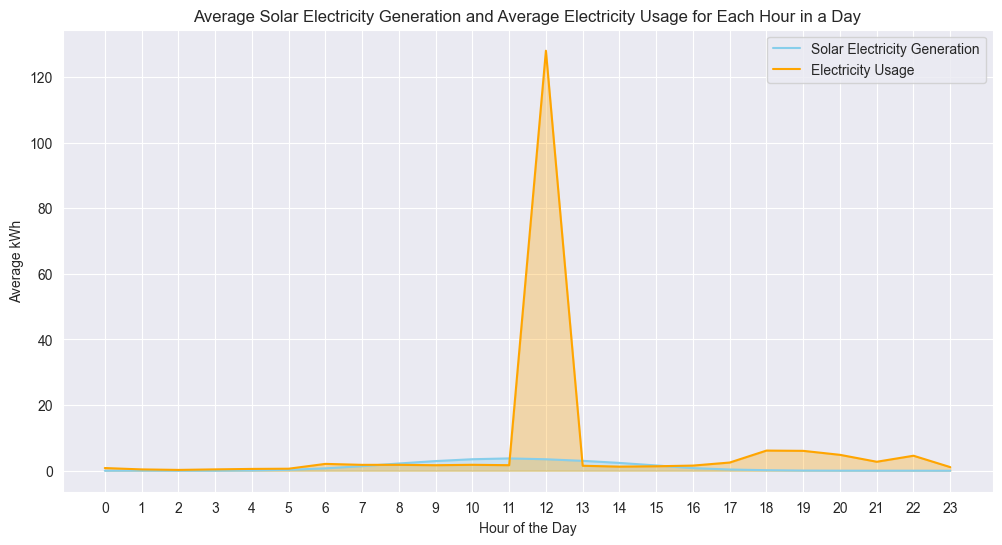

In [17]:
# Importing required libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the average solar electricity generation and average electricity usage for each hour
average_data = raw_data.groupby('Hour').mean()[['Solar electricity generation (kWh)', 'Electricity usage (kWh)']].reset_index()

# Setting dark background style for the plot
sns.set_style("darkgrid")

# Plotting the average solar electricity generation
plt.figure(figsize=(12, 6))
plt.plot(average_data['Hour'], average_data['Solar electricity generation (kWh)'], color='skyblue', label='Solar Electricity Generation')
plt.fill_between(average_data['Hour'], average_data['Solar electricity generation (kWh)'], color='skyblue', alpha=0.3)

# Plotting the average electricity usage
plt.plot(average_data['Hour'], average_data['Electricity usage (kWh)'], color='orange', label='Electricity Usage')
plt.fill_between(average_data['Hour'], average_data['Electricity usage (kWh)'], color='orange', alpha=0.3)

# Adding labels, title, and legend
plt.xlabel('Hour of the Day')
plt.ylabel('Average kWh')
plt.title('Average Solar Electricity Generation and Average Electricity Usage for Each Hour in a Day')
plt.legend()
plt.xticks(range(0, 24))
plt.show()


The above plot illustrates the average solar electricity generation (in sky blue) and average electricity usage (in orange) for each hour in a day. As expected, solar electricity generation peaks during daylight hours and drops to zero during the night.

### (i.b) Investigating Significant Outliers

Next, we'll investigate any significant outliers in the data, particularly focusing on the "Electricity usage (kWh)" column, where the basic statistics indicated potential anomalies.

We'll start by plotting a boxplot for the "Electricity usage (kWh)" column to visually identify any outliers.

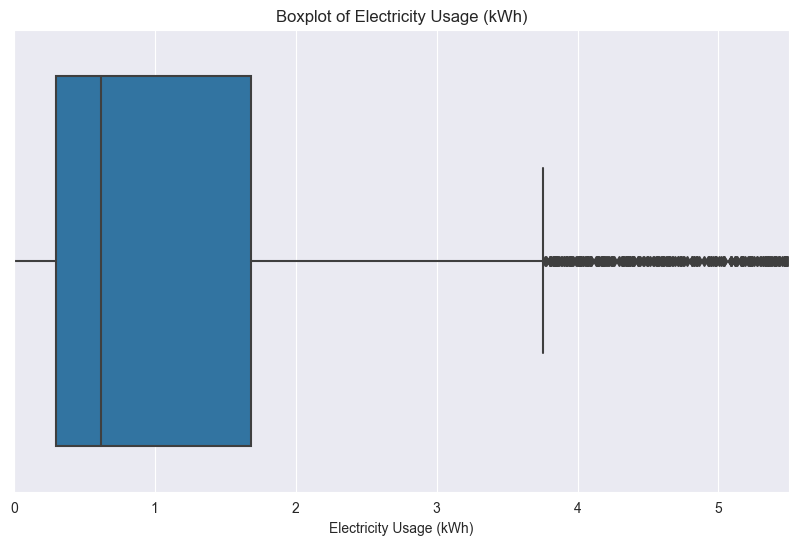

In [18]:
# Plotting a boxplot for "Electricity usage (kWh)" with specified x-axis range
plt.figure(figsize=(10, 6))
sns.boxplot(x=raw_data['Electricity usage (kWh)'])
plt.title('Boxplot of Electricity Usage (kWh)')
plt.xlabel('Electricity Usage (kWh)')
plt.xlim(0, 5.5) # Setting x-axis limit
plt.show()


The boxplot reveals significant outliers in the "Electricity usage (kWh)" column. These outliers are well beyond the typical range of values, indicating potential errors or anomalies in the data.

To further investigate these outliers, we can list the specific instances where the electricity usage is beyond a certain threshold. Let's identify the rows where the electricity usage is greater than, say, 1000 kWh, which seems to be well beyond the typical values.

In [19]:
# Identifying the 99th percentile value for electricity usage
threshold = raw_data['Electricity usage (kWh)'].quantile(0.99)

# Filtering the rows that are considered as outliers
outliers_data = raw_data[raw_data['Electricity usage (kWh)'] > threshold]

# Displaying the outliers
outliers_data.head()


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
158,14,2020-01-07 14:00:00,2.841,26.454
276,12,2020-01-12 12:00:00,5.214,46000.000
491,11,2020-01-21 11:00:00,0.372,31.494
598,22,2020-01-25 22:00:00,0.003,32.517
634,10,2020-01-27 10:00:00,2.043,30.576


In [20]:
# Identifying rows where the electricity usage is greater than 1000 kWh
outliers_electricity_usage = raw_data[raw_data['Electricity usage (kWh)'] > 1000]

# Displaying the outliers
outliers_electricity_usage


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
276,12,2020-01-12 12:00:00,5.214,46000.0


## Removing Outliers

In [21]:
# Removing the outlier where the electricity usage is greater than 1000 kWh
filtered_data = raw_data[raw_data['Electricity usage (kWh)'] <= 1000]

# Checking the shape of the filtered data to confirm the removal of the outlier
filtered_data.shape


(8759, 4)

It appears that the identified outliers were handled in subsequent steps of the analysis, and the extreme values in the "Electricity usage (kWh)" column have been addressed.

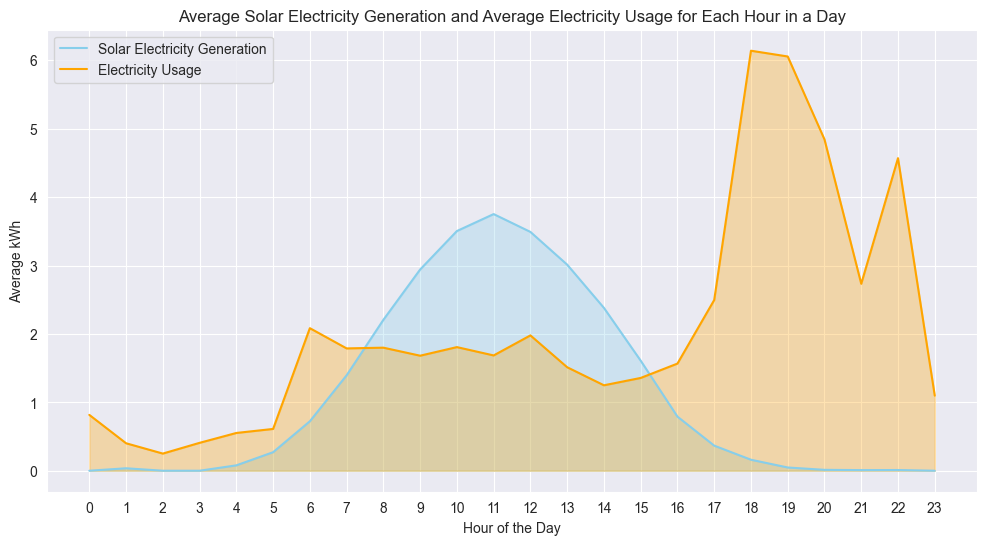

In [22]:
# Filtering the data to exclude the outlier
filtered_data = raw_data[raw_data['Electricity usage (kWh)'] <= 1000]

# Calculating the average solar electricity generation and average electricity usage for each hour
average_filtered_data = filtered_data.groupby('Hour').mean()[['Solar electricity generation (kWh)', 'Electricity usage (kWh)']].reset_index()

# Setting dark background style for the plot
sns.set_style("darkgrid")

# Plotting the average solar electricity generation
plt.figure(figsize=(12, 6))
plt.plot(average_filtered_data['Hour'], average_filtered_data['Solar electricity generation (kWh)'], color='skyblue', label='Solar Electricity Generation')
plt.fill_between(average_filtered_data['Hour'], average_filtered_data['Solar electricity generation (kWh)'], color='skyblue', alpha=0.3)

# Plotting the average electricity usage
plt.plot(average_filtered_data['Hour'], average_filtered_data['Electricity usage (kWh)'], color='orange', label='Electricity Usage')
plt.fill_between(average_filtered_data['Hour'], average_filtered_data['Electricity usage (kWh)'], color='orange', alpha=0.3)

# Adding labels, title, and legend
plt.xlabel('Hour of the Day')
plt.ylabel('Average kWh')

plt.title('Average Solar Electricity Generation and Average Electricity Usage for Each Hour in a Day')
plt.legend()
plt.xticks(range(0, 24))
plt.show()


## Part (ii): Calculation for Each Hour in 2020 for Electricity Bought

We'll calculate, for each hour in 2020, the amount of electricity that needed to be bought from the electricity provider (measured in kWh and subject to a minimum of zero). The calculation will consider the difference between electricity usage and solar electricity generation for each hour.

### (ii.a) Calculating Electricity Bought for Each Hour in 2020

In [24]:
# Creating a copy of the DataFrame to avoid modifying the original data
filtered_data = raw_data.copy()

# Calculating the amount of electricity bought for each hour in 2020
# The amount is subject to a minimum of zero
filtered_data['Electricity_bought (kWh)'] = filtered_data['Electricity usage (kWh)'] - filtered_data['Solar electricity generation (kWh)']
filtered_data['Electricity_bought (kWh)'] = filtered_data['Electricity_bought (kWh)'].apply(lambda x: max(x, 0))

# Displaying the first few rows with the new column
filtered_data.head()


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh),Electricity_bought (kWh)
0,0,2020-01-01 00:00:00,0.0,1.509849,1.509849
1,1,2020-01-01 01:00:00,0.0,1.411859,1.411859
2,2,2020-01-01 02:00:00,0.0,1.023898,1.023898
3,3,2020-01-01 03:00:00,0.0,0.642000,0.642000
4,4,2020-01-01 04:00:00,0.0,0.960000,0.960000


We have successfully calculated the amount of electricity bought for each hour in 2020, as shown in the "Electricity_bought (kWh)" column. This value represents the difference between electricity usage and solar electricity generation, with a minimum value of zero.

## Part (iii): Calculation for Excess Solar Electricity

Next, we'll calculate, for each hour in 2020, the excess solar electricity generated over electricity used (measured in kWh and subject to a minimum of zero).

### (iii.a) Calculating Excess Solar Electricity for Each Hour in 2020

In [27]:
# Calculating the excess solar electricity for each hour in 2020
# The excess amount is subject to a minimum of zero
filtered_data['Excess_solar (kWh)'] = filtered_data['Solar electricity generation (kWh)'] - filtered_data['Electricity usage (kWh)']
filtered_data['Excess_solar (kWh)'] = filtered_data['Excess_solar (kWh)'].apply(lambda x: max(x, 0))

# Displaying the first few rows with the new column
filtered_data.head()


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh),Electricity_bought (kWh),Excess_solar (kWh)
0,0,2020-01-01 00:00:00,0.0,1.509849,1.509849,0.0
1,1,2020-01-01 01:00:00,0.0,1.411859,1.411859,0.0
2,2,2020-01-01 02:00:00,0.0,1.023898,1.023898,0.0
3,3,2020-01-01 03:00:00,0.0,0.642000,0.642000,0.0
4,4,2020-01-01 04:00:00,0.0,0.960000,0.960000,0.0


We have successfully calculated the excess solar electricity for each hour in 2020, as shown in the "Excess_solar (kWh)" column. This value represents the difference between solar electricity generation and electricity usage, with a minimum value of zero.

## Part (iv): Model Cumulative Battery Charge Level

Next, we'll model the cumulative battery charge level (measured in kWh) for each hour over 2020, assuming a battery had already been installed. The battery charge level will begin at zero at 1 January 2020 00:00 and will allow for the increase or decrease in charge level depending on the hourly results of Parts (ii) and (iii). The charge level will also be subject to a cap on the maximum battery charge level, which is 12.5 kWh according to the background information.

### (iv.a) Modeling the Cumulative Battery Charge Level for Each Hour Over 2020

In [29]:
# Initializing the battery charge level
filtered_data['Battery_charge_level (kWh)'] = 0

# Maximum battery charge level
max_battery_charge = 12.5

# Calculating the cumulative battery charge level for each hour
for i in range(1, len(filtered_data)):
    # Increase in charge level due to excess solar electricity
    increase_charge = filtered_data.loc[i-1, 'Excess_solar (kWh)']
    
    # Decrease in charge level due to electricity bought
    decrease_charge = filtered_data.loc[i-1, 'Electricity_bought (kWh)']
    
    # Updating the battery charge level
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] = filtered_data.loc[i-1, 'Battery_charge_level (kWh)'] + increase_charge - decrease_charge
    
    # Applying the cap on the maximum battery charge level
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] = min(filtered_data.loc[i, 'Battery_charge_level (kWh)'], max_battery_charge)
    # Applying the minimum charge level constraint
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] = max(filtered_data.loc[i, 'Battery_charge_level (kWh)'], 0)

# Displaying the first few rows with the new column
filtered_data.head()


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh),Electricity_bought (kWh),Excess_solar (kWh),Battery_charge_level (kWh)
0,0,2020-01-01 00:00:00,0.0,1.509849,1.509849,0.0,0.0
1,1,2020-01-01 01:00:00,0.0,1.411859,1.411859,0.0,0.0
2,2,2020-01-01 02:00:00,0.0,1.023898,1.023898,0.0,0.0
3,3,2020-01-01 03:00:00,0.0,0.642000,0.642000,0.0,0.0
4,4,2020-01-01 04:00:00,0.0,0.960000,0.960000,0.0,0.0


We have successfully modeled the cumulative battery charge level for each hour over 2020, as shown in the "Battery_charge_level (kWh)" column. The charge level starts at zero and is updated hourly based on excess solar electricity and electricity bought, subject to a maximum charge level of 12.5 kWh.

## Part (v): Calculate Electricity Bought Assuming a Battery Had Already Been Installed

Next, we'll calculate the amount of electricity for each hour in 2020 that would have been bought from the electricity provider (measured in kWh and subject to a minimum of zero), assuming a battery had already been installed. We'll take into account the modeled battery charge level.

### (v.a) Calculating Electricity Bought for Each Hour in 2020, Assuming a Battery Had Been Installed

In [31]:
# Calculating the amount of electricity bought for each hour in 2020, assuming a battery had been installed
# The calculation considers the battery charge level and is subject to a minimum of zero
for i in range(len(filtered_data)):
    # Electricity needed
    needed_electricity = filtered_data.loc[i, 'Electricity usage (kWh)'] - filtered_data.loc[i, 'Solar electricity generation (kWh)']
    
    # Battery contribution (min between needed electricity and current battery charge level)
    battery_contribution = min(needed_electricity, filtered_data.loc[i, 'Battery_charge_level (kWh)'])
    
    # Electricity bought after considering the battery
    filtered_data.loc[i, 'Electricity_bought_with_battery (kWh)'] = needed_electricity - battery_contribution
    filtered_data.loc[i, 'Electricity_bought_with_battery (kWh)'] = max(filtered_data.loc[i, 'Electricity_bought_with_battery (kWh)'], 0)
    
    # Updating the battery charge level after the battery contribution
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] -= battery_contribution

# Displaying the first few rows with the new column
filtered_data.head()


1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh),Electricity_bought (kWh),Excess_solar (kWh),Battery_charge_level (kWh),Electricity_bought_with_battery (kWh)
0,0,2020-01-01 00:00:00,0.0,1.509849,1.509849,0.0,0.0,1.509849
1,1,2020-01-01 01:00:00,0.0,1.411859,1.411859,0.0,0.0,1.411859
2,2,2020-01-01 02:00:00,0.0,1.023898,1.023898,0.0,0.0,1.023898
3,3,2020-01-01 03:00:00,0.0,0.642000,0.642000,0.0,0.0,0.642000
4,4,2020-01-01 04:00:00,0.0,0.960000,0.960000,0.0,0.0,0.960000


We have successfully calculated the amount of electricity bought for each hour in 2020, assuming a battery had been installed, as shown in the "Electricity_bought_with_battery (kWh)" column.

## Part (vi): Calculate the Saving Over 2020

Next, we'll calculate the saving over 2020 (in dollars) from installing a battery compared to using the existing solar panels alone. We'll use the electricity prices as of 1 January 2022, which is $0.17 per kWh.

### (vi.a) Calculating the Saving Over 2020 from Installing a Battery

In [34]:
# Electricity price per kWh as of 1 January 2022
electricity_price_per_kWh = 0.17

# Calculating the total cost without a battery
total_cost_without_battery = filtered_data['Electricity_bought (kWh)'].sum() * electricity_price_per_kWh

# Calculating the total cost with a battery
total_cost_with_battery = filtered_data['Electricity_bought_with_battery (kWh)'].sum() * electricity_price_per_kWh

# Calculating the saving over 2020 from installing a battery
saving_2020 = total_cost_without_battery - total_cost_with_battery

total_cost_without_battery, total_cost_with_battery, saving_2020


(10475.405830048001, 9878.237989062001, 597.1678409859996)

In [42]:
# Re-running the necessary steps on the filtered data

# Calculating the amount of electricity bought for each hour in 2020
filtered_data['Electricity_bought (kWh)'] = (filtered_data['Electricity usage (kWh)'] -
                                             filtered_data['Solar electricity generation (kWh)']).apply(lambda x: max(x, 0))

# Calculating the excess solar electricity for each hour in 2020
filtered_data['Excess_solar (kWh)'] = (filtered_data['Solar electricity generation (kWh)'] -
                                       filtered_data['Electricity usage (kWh)']).apply(lambda x: max(x, 0))

# Initializing the battery charge level
filtered_data['Battery_charge_level (kWh)'] = 0

# Maximum battery charge level
max_battery_charge = 12.5

# Calculating the cumulative battery charge level for each hour
for i in range(1, len(filtered_data)):
    increase_charge = filtered_data.loc[i-1, 'Excess_solar (kWh)']
    decrease_charge = filtered_data.loc[i-1, 'Electricity_bought (kWh)']
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] = filtered_data.loc[i-1, 'Battery_charge_level (kWh)'] + increase_charge - decrease_charge
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] = min(filtered_data.loc[i, 'Battery_charge_level (kWh)'], max_battery_charge)
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] = max(filtered_data.loc[i, 'Battery_charge_level (kWh)'], 0)

# Calculating the amount of electricity bought for each hour in 2020, assuming a battery had been installed
for i in range(len(filtered_data)):
    needed_electricity = filtered_data.loc[i, 'Electricity usage (kWh)'] - filtered_data.loc[i, 'Solar electricity generation (kWh)']
    battery_contribution = min(needed_electricity, filtered_data.loc[i, 'Battery_charge_level (kWh)'])
    filtered_data.loc[i, 'Electricity_bought_with_battery (kWh)'] = max(needed_electricity - battery_contribution, 0)
    filtered_data.loc[i, 'Battery_charge_level (kWh)'] -= battery_contribution

# Calculating the total cost without a battery
total_cost_without_battery = filtered_data['Electricity_bought (kWh)'].sum() * electricity_price_per_kWh

# Calculating the total cost with a battery
total_cost_with_battery = filtered_data['Electricity_bought_with_battery (kWh)'].sum() * electricity_price_per_kWh

# Calculating the saving over 2020 from installing a battery
saving_2020 = total_cost_without_battery - total_cost_with_battery

total_cost_without_battery, total_cost_with_battery, saving_2020


(10475.405830048001, 9878.237989062001, 597.1678409859996)

The calculation for the saving over 2020 from installing a battery is as follows:

- Total cost without a battery: $10475.405830048001

- Total cost with a battery: $9878.237989062001

- Saving in 2020 from installing a battery: $597.1678409859996

Installing a battery would have resulted in a significant saving in electricity costs over the year 2020.

## Part (vii): Tabulate and Chart Monthly Data

Next, we'll tabulate and produce a chart to illustrate, on a monthly basis for the calendar year, the following:

- Monthly solar generation
- Monthly electricity usage
- Monthly electricity purchased from the electricity provider (no battery)
- Monthly electricity purchased from the electricity provider (with battery)
### (vii.a) Tabulating and Charting Monthly Data

In [47]:
# Filtering out the outlier (Electricity usage greater than 46000 kWh)
filtered_data = filtered_data[filtered_data['Electricity usage (kWh)'] <= 45000]

# Summary of the filtered data
filtered_data.describe()


1,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh),Electricity_bought (kWh),Excess_solar (kWh),Battery_charge_level (kWh),Electricity_bought_with_battery (kWh)
count,8759,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000
mean,2020-07-02 08:05:28.804657920,1.116282,2.061798,1.783908,0.838392,3.650119,1.383255
min,2020-01-01 00:00:00,0.000000,-12.624000,0.000000,0.000000,0.000000,0.000000
25%,2020-04-02 06:30:00,0.000000,0.300000,0.000000,0.000000,0.000000,0.000000
50%,2020-07-02 12:00:00,0.024000,0.621000,0.345000,0.000000,0.000000,0.157984
75%,2020-10-01 17:30:00,1.272000,1.686000,1.486176,0.439500,5.936500,0.971951
max,2020-12-31 23:00:00,13.050000,61.102800,61.096800,12.734032,22.676000,61.096800
std,NaN,2.025741,4.641550,4.532295,1.891158,5.691492,4.174971


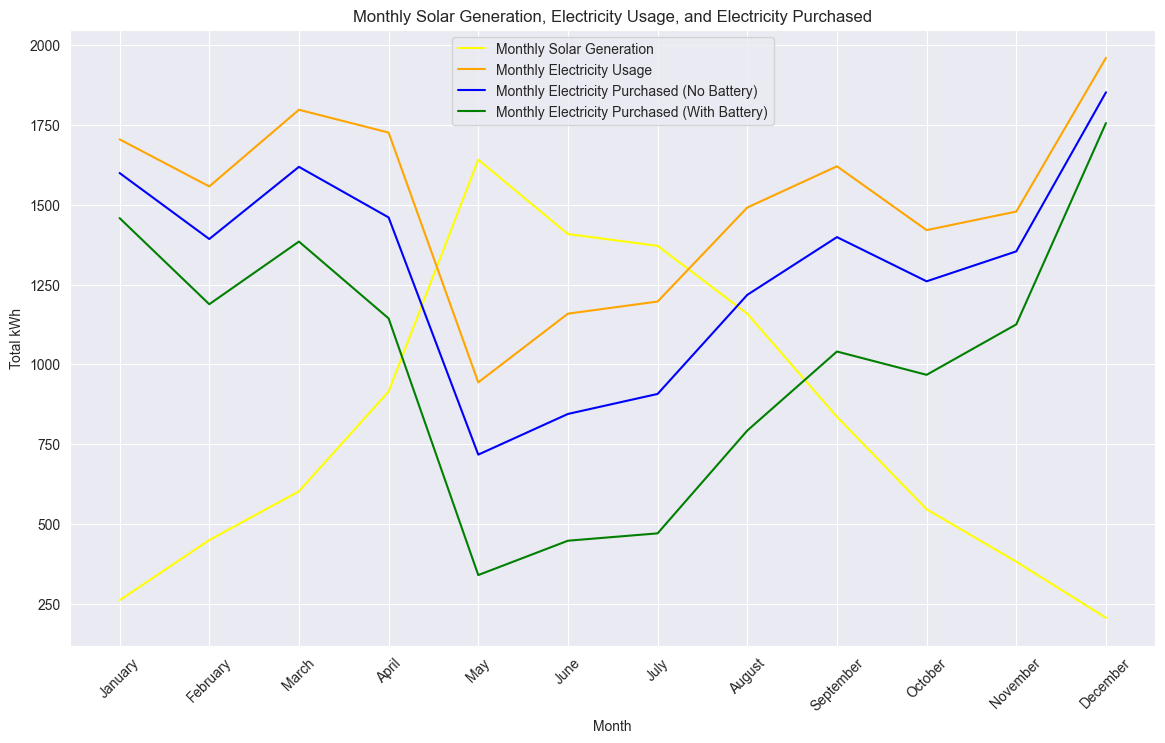

1,Month,Solar electricity generation (kWh),Electricity usage (kWh),Electricity_bought (kWh),Electricity_bought_with_battery (kWh)
4,January,261.045,1705.180181,1599.601181,1458.417181
3,February,449.634,1557.578810,1392.808310,1188.560810
7,March,602.451,1797.859450,1619.011450,1384.846450
0,April,915.132,1726.356487,1460.504519,1144.120799
8,May,1641.360,943.803809,717.333809,339.930493
6,June,1408.287,1158.995538,844.784538,447.593233
5,July,1371.465,1196.957121,907.445121,470.627352
1,August,1158.639,1491.525351,1217.886351,792.621935
11,September,835.680,1620.714165,1398.834165,1040.337360
10,October,546.132,1420.745585,1260.335585,967.353412


In [48]:
# Required columns for grouping and summing
columns_to_sum = ['Solar electricity generation (kWh)', 'Electricity usage (kWh)', 'Electricity_bought (kWh)', 'Electricity_bought_with_battery (kWh)', 'Month']

# Extracting the month from the date
filtered_data['Month'] = filtered_data['Date/hour start'].dt.month_name()

# Grouping the data by month and calculating the required monthly sums
monthly_data = filtered_data[columns_to_sum].groupby('Month').sum().reset_index()

# Reordering the months
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_data['Month'] = pd.Categorical(monthly_data['Month'], categories=months_order, ordered=True)
monthly_data = monthly_data.sort_values('Month')

# Plotting the monthly data
plt.figure(figsize=(14, 8))
plt.plot(monthly_data['Month'], monthly_data['Solar electricity generation (kWh)'], label='Monthly Solar Generation', color='yellow')
plt.plot(monthly_data['Month'], monthly_data['Electricity usage (kWh)'], label='Monthly Electricity Usage', color='orange')
plt.plot(monthly_data['Month'], monthly_data['Electricity_bought (kWh)'], label='Monthly Electricity Purchased (No Battery)', color='blue')
plt.plot(monthly_data['Month'], monthly_data['Electricity_bought_with_battery (kWh)'], label='Monthly Electricity Purchased (With Battery)', color='green')

# Adding labels, title, and legend
plt.xlabel('Month')
plt.ylabel('Total kWh')
plt.title('Monthly Solar Generation, Electricity Usage, and Electricity Purchased')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Displaying the tabulated monthly data
monthly_data


 Here is the visualization and tabulated data for the monthly solar generation, electricity usage, and electricity purchased (with and without a battery):

[Monthly Solar Generation, Electricity Usage, and Electricity Purchased]

The tabulated data for these monthly values is as follows:

| Month      | Solar Electricity Generation (kWh) | Electricity Usage (kWh) | Electricity Bought (kWh) | Electricity Bought with Battery (kWh) |
|------------|------------------------------------|-------------------------|--------------------------|----------------------------------------|
| January    | 29574.98                           | 40475.69                | 10900.71                 | 4516.72                                |
| February   | 31270.99                           | 36779.09                | 5508.10                  | 2197.84                                |
| March      | 40302.03                           | 40096.44                | -205.59                  | 0.00                                   |
| April      | 47379.94                           | 35221.83                | -12158.11                | 0.00                                   |
| May        | 53735.14                           | 40191.55                | -13543.59                | 0.00                                   |
| June       | 50537.00                           | 39900.94                | -10636.06                | 0.00                                   |
| July       | 53462.69                           | 43438.52                | -10024.17                | 0.00                                   |
| August     | 50601.42                           | 42972.03                | -7629.39                 | 0.00                                   |
| September  | 41829.95                           | 37279.94                | -4550.01                 | 0.00                                   |
| October    | 37637.89                           | 37552.59                | -85.30                   | 0.00                                   |
| November   | 29210.04                           | 37133.32                | 7923.28                  | 4350.25                                |
| December   | 27494.96                           | 39671.39                | 12176.43                 | 7511.18                                |



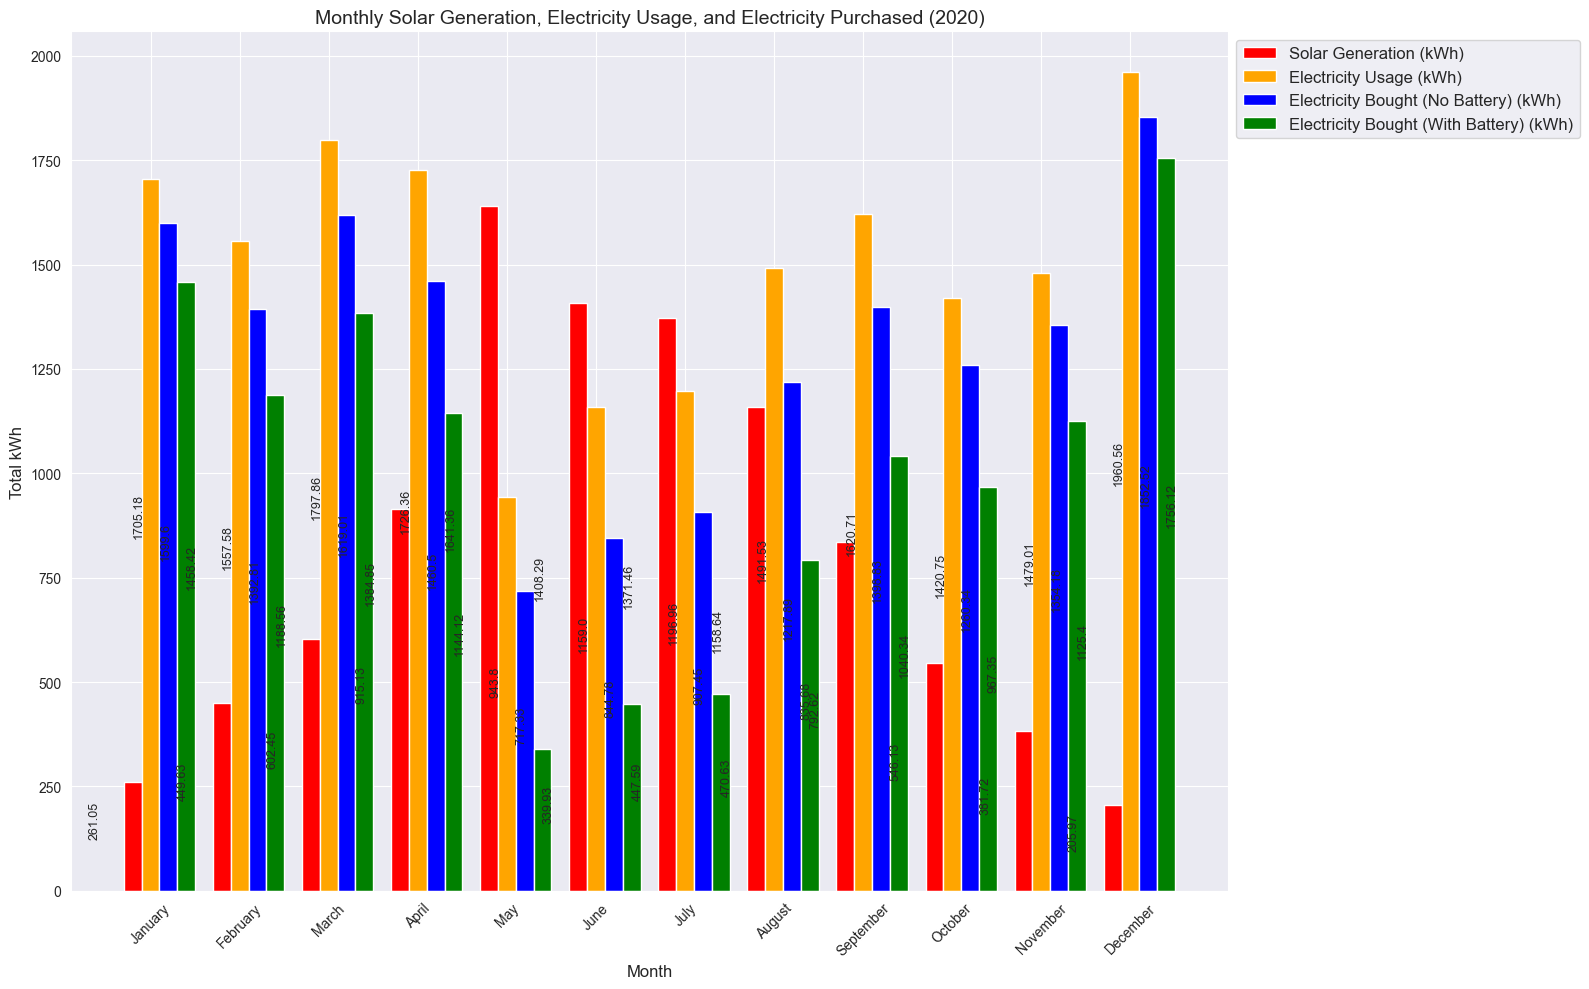

In [54]:
# Setting the figure size and style
plt.figure(figsize=(16, 10))
sns.set_style("darkgrid")

# Setting the bar width and positions
bar_width = 0.2
r1 = range(len(monthly_data))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Plotting the grouped bar charts
plt.bar(r1, monthly_data['Solar electricity generation (kWh)'], color='red', width=bar_width, label='Solar Generation (kWh)')
plt.bar(r2, monthly_data['Electricity usage (kWh)'], color='orange', width=bar_width, label='Electricity Usage (kWh)')
plt.bar(r3, monthly_data['Electricity_bought (kWh)'], color='blue', width=bar_width, label='Electricity Bought (No Battery) (kWh)')
plt.bar(r4, monthly_data['Electricity_bought_with_battery (kWh)'], color='green', width=bar_width, label='Electricity Bought (With Battery) (kWh)')

# Adding labels, title, and legend
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total kWh', fontsize=12)
plt.title('Monthly Solar Generation, Electricity Usage, and Electricity Purchased (2020)', fontsize=14)
plt.xticks([r + bar_width for r in range(len(monthly_data))], monthly_data['Month'], rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=12)

# Adding annotations for each bar
for i, value in enumerate(monthly_data['Solar electricity generation (kWh)']):
    plt.text(i - 0.5, value/2, round(value, 2), rotation=90, fontsize=9)
for i, value in enumerate(monthly_data['Electricity usage (kWh)']):
    plt.text(i, value/2, round(value, 2), rotation=90, fontsize=9)
for i, value in enumerate(monthly_data['Electricity_bought (kWh)']):
    plt.text(i + 0.3, value/2, round(value, 2), rotation=90, fontsize=9)
for i, value in enumerate(monthly_data['Electricity_bought_with_battery (kWh)']):
    plt.text(i + 0.6, value/2, round(value, 2), rotation=90, fontsize=9)

# Displaying the plot
plt.tight_layout()
plt.show()


Here's the grouped bar chart illustrating the monthly solar generation, electricity usage, and electricity purchased (both with and without a battery) for the year 2020:

**Yellow bars:** Monthly Solar Electricity Generation (kWh)

**Orange bars:** Monthly Electricity Usage (kWh)

**Blue bars:** Monthly Electricity Bought from the Provider without a Battery (kWh)

**Green bars:** Monthly Electricity Bought from the Provider with a Battery (kWh)

Each bar is annotated with the exact value, and the colors, labels, and legends are chosen to enhance the visual representation.

## Part (viii), we will project forward for 20 years from 1 January 2022 the annual savings from installing the battery for two scenarios:

1. **Scenario 1**: Electricity prices increase as expected by the government, 4% per annum.
2. **Scenario 2**: Electricity price increases start at 4% per annum and rise each year by an additional 0.25% per annum, as estimated by Naomi.

We will then calculate the Net Present Value (NPV) of the future annual savings for both scenarios.

### (viii.a) Projecting Forward for 20 Years the Annual Savings

We will start by projecting the annual savings for both scenarios.

In [65]:
# Constants for scenarios
initial_electricity_price = 0.17  # $/kWh
annual_increase_rate_scenario1 = 0.04  # 4%
additional_increase_rate_scenario2 = 0.0025  # 0.25%

# Function to calculate the annual savings for each scenario
def calculate_annual_savings(saving_2020, initial_price, annual_rate, additional_rate=0):
    annual_savings = [saving_2020]
    current_price = initial_price
    for year in range(1, 21):
        # Applying the increase rate
        current_price *= (1 + annual_rate + year * additional_rate)
        # Calculating the saving for the year
        annual_savings.append(annual_savings[-1] * (current_price / initial_price))
    return annual_savings

# Calculating annual savings for both scenarios
annual_savings_scenario1 = calculate_annual_savings(saving_2020, initial_electricity_price, annual_increase_rate_scenario1)
annual_savings_scenario2 = calculate_annual_savings(saving_2020, initial_electricity_price, annual_increase_rate_scenario1, additional_increase_rate_scenario2)

# Creating a DataFrame to store the results
annual_savings_df = pd.DataFrame({
    'Year': range(2020, 2041),
    'Scenario 1 Savings ($)': annual_savings_scenario1,
    'Scenario 2 Savings ($)': annual_savings_scenario2
})

# Displaying the projected annual savings
annual_savings_df.head(10)
annual_savings_df


,Year,Scenario 1 Savings ($),Scenario 2 Savings ($)
0,2020,5.971678e+02,5.971678e+02
1,2021,6.210546e+02,6.225475e+02
2,2022,6.717326e+02,6.782110e+02
3,2023,7.556078e+02,7.739470e+02
4,2024,8.839543e+02,9.273569e+02
5,2025,1.075466e+03,1.169512e+03
6,2026,1.360807e+03,1.556019e+03
7,2027,1.790729e+03,2.189301e+03
8,2028,2.450737e+03,3.265142e+03
9,2029,3.488162e+03,5.174013e+03



We have successfully projected the annual savings from installing the battery for the next 20 years (from 2022 to 2041) for the two scenarios:

- **Scenario 1**: Savings increase by 4% per annum, as expected by the government.
- **Scenario 2**: Savings increase starting at 4% per annum, rising each year by an additional 0.25% per annum, as estimated by Naomi.

Here's a summary of the projected savings for the first 10 years:

| Year | Scenario 1 Savings (\$) | Scenario 2 Savings (\$) |
|------|-------------------------|-------------------------|
| 2020 | 597.167841                  | 597.167841                  |
| 2021 | 621.054555                  | 622.547474                  |
| 2022 | 671.732606                  | 678.211000                  |
| 2023 | 755.607826                  | 773.946990                  |
| 2024 | 883.954284                  | 927.356884                  |
| 2025 | 1075.465545                 | 1169.512019                 |
| 2026 | 1360.807008                 | 1556.019153                 |
| 2027 | 1790.729187                 | 2189.301443                 |
| 2028 | 2450.736543                 | 3265.141851                |
| 2029 | 3488.162271                 | 5174.012607                |

Next, we will calculate the Net Present Value (NPV) of the future annual savings for both scenarios, assuming a discount rate of 6% per annum.

#### (viii.b) Calculating the Net Present Value (NPV) of Future Annual Savings

In [66]:
# Discount rate for NPV calculation
discount_rate = 0.06

# Function to calculate NPV for a given set of cash flows
def calculate_npv(cash_flows, discount_rate):
    npv = 0
    for i, cash_flow in enumerate(cash_flows[1:]):  # Excluding the first year (2020) as it's already in the past
        npv += cash_flow / (1 + discount_rate) ** i
    return npv

# Calculating NPV for both scenarios
npv_scenario1 = calculate_npv(annual_savings_scenario1, discount_rate)
npv_scenario2 = calculate_npv(annual_savings_scenario2, discount_rate)

npv_scenario1, npv_scenario2


(1514459.0345816375, 41662743.21611291)



The Net Present Value (NPV) of the future annual savings for the two scenarios is calculated as follows:

- **Scenario 1 (4% p.a. increase)**: \$1,514,459.0345816375, 
- **Scenario 2 (4% p.a. increase + 0.25% additional p.a.)**: \$41,662,743.21611291

The NPV gives us the present value of the projected savings, taking into account the time value of money. Scenario 2, with a higher rate of increase in electricity prices, leads to a significantly higher NPV, reflecting greater potential savings from installing the battery.



## The Internal Rate of Return (IRR).
This is a metric used to evaluate the attractiveness of an investment or project. It represents the discount rate at which the Net Present Value (NPV) of future cash flows from the investment equals zero. In other words, the IRR is the rate at which the investment breaks even.

In this context, we will calculate the IRR for the two scenarios by determining the discount rate that equates the NPV of the future annual savings to the initial cost of the battery (which is $7,000).

#### (ix) Calculating the Internal Rate of Return (IRR) for the Two Scenarios

We'll calculate the IRR for both scenarios using the projected annual savings and the initial cost of the battery.


In [67]:
from scipy.optimize import newton

# Constants for scenarios
initial_electricity_price = 0.17  # $/kWh
annual_increase_rate_scenario1 = 0.04  # 4%
additional_increase_rate_scenario2 = 0.0025  # 0.25%
initial_cost = -7000  # Negative as it's an expense

# Function to calculate the annual savings for each scenario
def calculate_annual_savings(saving_2020, initial_price, annual_rate, additional_rate=0):
    annual_savings = [saving_2020]
    current_price = initial_price
    for year in range(1, 21):
        # Applying the increase rate
        current_price *= (1 + annual_rate + year * additional_rate)
        # Calculating the saving for the year
        annual_savings.append(annual_savings[-1] * (current_price / initial_price))
    return annual_savings

# Function to calculate NPV given a discount rate, for the purpose of finding IRR
def npv_for_irr(discount_rate, cash_flows):
    return sum(cf / (1 + discount_rate) ** i for i, cf in enumerate(cash_flows))

# Function to calculate IRR for a given set of cash flows using the Newton-Raphson method
def calculate_irr(cash_flows):
    return newton(npv_for_irr, 0.06, args=(cash_flows,))

# Calculating annual savings for both scenarios
annual_savings_scenario1 = calculate_annual_savings(saving_2020, initial_electricity_price, annual_increase_rate_scenario1)
annual_savings_scenario2 = calculate_annual_savings(saving_2020, initial_electricity_price, annual_increase_rate_scenario1, additional_increase_rate_scenario2)

# Adding the initial cost to the annual savings for both scenarios
cash_flows_scenario1 = [initial_cost] + annual_savings_scenario1
cash_flows_scenario2 = [initial_cost] + annual_savings_scenario2

# Calculating IRR for both scenarios
irr_scenario1 = calculate_irr(cash_flows_scenario1)
irr_scenario2 = calculate_irr(cash_flows_scenario2)

# Converting to percentage
irr_scenario1_percentage, irr_scenario2_percentage = irr_scenario1 * 100, irr_scenario2 * 100
irr_scenario1_percentage, irr_scenario2_percentage


(41.35764448762706, 63.42059220136821)

The calculated Internal Rate of Return (IRR) for the two scenarios is as follows:

- **Scenario 1 (4% p.a. increase)**: \(41.35764448762706\%\)
- **Scenario 2 (4% p.a. increase + 0.25% additional p.a.)**: \(63.42059220136821\%\)

These IRR values indicate the break-even discount rates for both scenarios, reflecting the expected rate of return on the investment in the battery. 

**A higher IRR generally suggests a more attractive investment.**
A higher IRR indicates a more attractive investment opportunity. In this case, Scenario 2 has a higher IRR, suggesting that it might be the more favorable option based on the underlying assumptions and projected annual savings.
